C:\Users\proko\AppData\Local\Temp\ipykernel_34104\4011265643.py:7: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dataset = read_csv( 'household_power_consumption.csv' , header=0, infer_datetime_format=True, parse_dates=['datetime'], index_col=['datetime'])


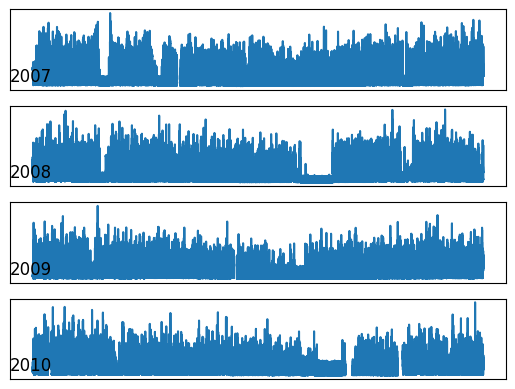

In [2]:
# yearly line plots for power usage dataset
from pandas import read_csv
from matplotlib import pyplot
import io
import psycopg2
# load the new file
dataset = read_csv( 'household_power_consumption.csv' , header=0, infer_datetime_format=True, parse_dates=['datetime'], index_col=['datetime'])
# plot active power for each year
years = [2007, 2008 , 2009 , 2010]
pyplot.figure()
for i, year in enumerate(years):
    # prepare subplot
    ax = pyplot.subplot(len(years), 1, i+1)

    # get all observations for the year using datetime indexing
    result = dataset[dataset.index.year == year]

    # plot the active power for the year
    pyplot.plot(result.index, result['Global_active_power'])

    # add a title to the subplot
    pyplot.title(str(year), y=0, loc='left')

    # turn off ticks to remove clutter
    pyplot.yticks([])
    pyplot.xticks([])

pyplot.show()

# Save the plot to an in-memory buffer
buf = io.BytesIO()
pyplot.savefig(buf, format='png')
pyplot.close()
buf.seek(0)

# Connect to PostgreSQL
conn = psycopg2.connect(
    host="localhost",
    database="Bitirme",
    user="postgres",
    password="167943"
)
cur = conn.cursor()

b = None

with open("yearly.png", "rb") as image:
    f = image.read()
    b = bytearray(f)
	
cur.execute("INSERT INTO years (graph_data) VALUES (%s)", (b,))
# Insert the image into the PostgreSQL table
binary_data = psycopg2.Binary(buf.read())
conn.commit()

# Close the connection
cur.close()
conn.close()

C:\Users\proko\AppData\Local\Temp\ipykernel_28396\3228413361.py:5: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dataset = read_csv( 'household_power_consumption.csv' , header=0, infer_datetime_format=True, parse_dates=['datetime'], index_col=['datetime'])


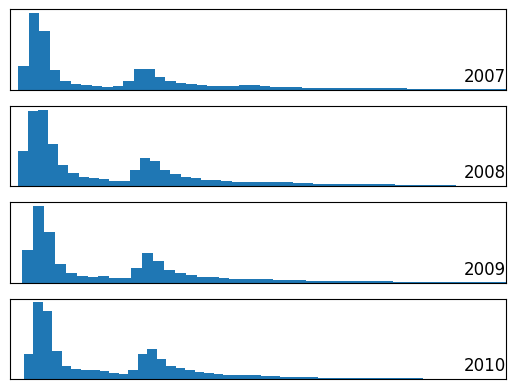

In [2]:
# yearly histogram plots for power usage dataset
from pandas import read_csv
from matplotlib import pyplot
# load the new file
dataset = read_csv( 'household_power_consumption.csv' , header=0, infer_datetime_format=True, parse_dates=['datetime'], index_col=['datetime'])
# plot active power histogram for each year
years = [2007, 2008, 2009, 2010]
pyplot.figure()

for i, year in enumerate(years):
    # prepare subplot
    ax = pyplot.subplot(len(years), 1, i+1)
    
    # filter the dataset for the specific year
    year_data = dataset[dataset.index.year == year]
    
    # plot the histogram of active power for the year
    year_data['Global_active_power'].hist(bins=100)
    
    # zoom in on the distribution
    ax.set_xlim(0, 5)
    
    # add a title to the subplot
    pyplot.title(year, y=0, loc='right')
    
    # turn off ticks to remove clutter
    pyplot.yticks([])
    pyplot.xticks([])

pyplot.show()